<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Box Plots**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2026-06-11 02:54:02--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-results-public.sqlite.2’

survey-results-publ 100%[===================>] 201.62M  45.9MB/s    in 4.6s    

2026-06-11 02:54:14 (43.4 MB/s) - ‘survey-results-public.sqlite.2’ saved [211415040/211415040]



#### 2. Connect to the Database


**Install the needed libraries**


In [2]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 151.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 178.8 MB/s eta 0:00:00


In [3]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 154.8 MB/s eta 0:00:00


In [4]:
!pip install seaborn

In [5]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Connect to the SQLite database
conn = sqlite3.connect('survey-results-public.sqlite')


## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [5]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


#### Demo 2: List All Tables


In [6]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


#### Demo 3: Group Data by Age


In [7]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


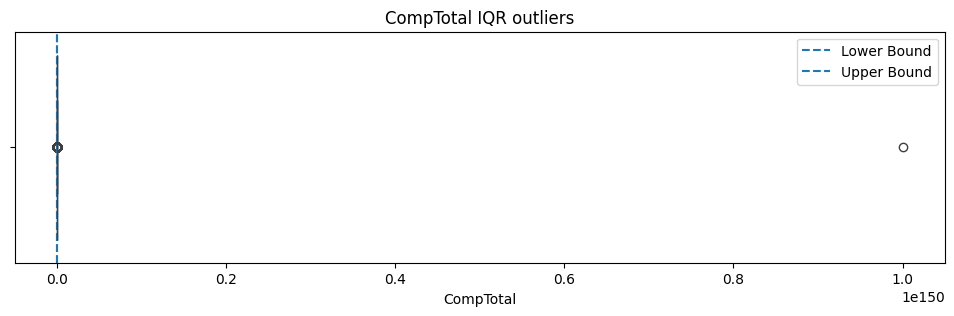

In [6]:
# your code goes here
query = """
SELECT CompTotal
FROM main
WHERE CompTotal IS NOT NULL
"""
df_comp = pd.read_sql_query(query , conn)

q1_compy = df_comp['CompTotal'].describe()['25%']
q3_compy = df_comp['CompTotal'].describe()['75%']
iqr_compy = q3_compy - q1_compy
Lbound_compy = q1_compy - 1.5 * iqr_compy
Ubound_compy = q3_compy + 1.5 * iqr_compy
iqr_outliers = df_comp[(df_comp['CompTotal'] < Lbound_compy) | (df_comp['CompTotal'] > Ubound_compy)]
iqr_outliers.drop(labels = 8262 , inplace = True)
#iqr_outliers['CompTotal'].sort_values(ascending = False)
plt.figure(figsize = (12 , 3))
sns.boxplot(x = df_comp['CompTotal'])
plt.axvline(Lbound_compy , linestyle = '--' , label = 'Lower Bound')
plt.axvline(Ubound_compy , linestyle = '--' , label = 'Upper Bound')
plt.title('CompTotal IQR outliers')
plt.xlabel('CompTotal')
plt.legend()

plt.show()

**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


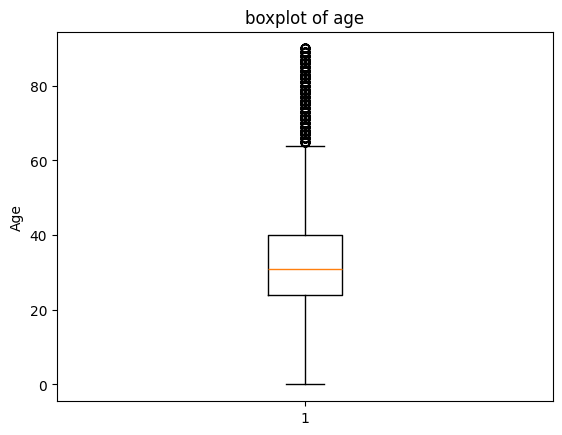

In [7]:
# your code goes here
query = """
SELECT Age
FROM main
WHERE Age IS NOT NULL
"""

df_age = pd.read_sql_query(query , conn)

import numpy as np
age_ranges = {
    'Under 18 years old': (0, 17),
    '18-24 years old': (18, 24),
    '25-34 years old': (25, 34),
    '35-44 years old': (35, 44),
    '45-54 years old': (45, 54),
    '55-64 years old': (55, 64),
    '65 years or older': (65, 90),
    'Prefer not to say': (0 , 90)
}

def random_age(age_grp):
    if age_grp in age_ranges:
        low , high = age_ranges[age_grp]
        return np.random.randint(low , high + 1)
    return np.nan

df_age['AgeNumber'] = df_age['Age'].apply(random_age)

plt.boxplot(df_age['AgeNumber'])
plt.ylabel('Age')
plt.title('boxplot of age')
plt.show()

### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


/tmp/ipykernel_301/3605838494.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([compage25_34 , compage35_44 , compage18_24 , compage45_54 , compage55_64] , labels = labels)


Text(0, 0.5, 'total comp')

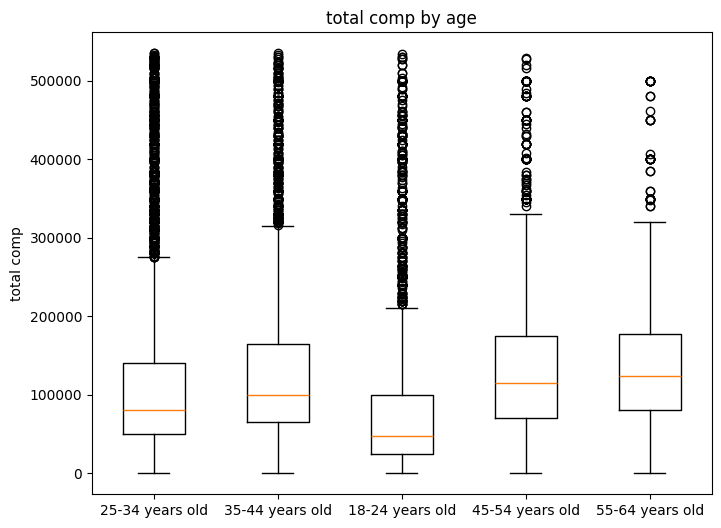

In [8]:
# your code goes here
query = """
SELECT CompTotal , Age
FROM main
WHERE CompTotal IS NOT NULL
AND Age IS NOT NULL
"""

df_compage = pd.read_sql_query(query , conn)
q1_compage = df_compage['CompTotal'].describe()['25%']
q3_compage = df_compage['CompTotal'].describe()['75%']
iqr_compage = q3_compage - q1_compage
Lbound_compage = q1_compage - 1.5 * iqr_compage
Ubound_compage = q3_compage + 1.5 * iqr_compage
df_compage = df_compage[(df_compage['CompTotal'] >= Lbound_compage) & (df_compage['CompTotal'] <= Ubound_compage)]
compage25_34 = df_compage.loc[df_compage['Age'] == '25-34 years old' , 'CompTotal']
compage35_44 = df_compage.loc[df_compage['Age'] == '35-44 years old' , 'CompTotal']
compage18_24 = df_compage.loc[df_compage['Age'] == '18-24 years old' , 'CompTotal']
compage45_54 = df_compage.loc[df_compage['Age'] == '45-54 years old' , 'CompTotal']
compage55_64 = df_compage.loc[df_compage['Age'] == '55-64 years old' , 'CompTotal']
labels = ['25-34 years old' , '35-44 years old' , '18-24 years old' , '45-54 years old' , '55-64 years old']
fig , ax = plt.subplots(figsize = (8 , 6))

ax.boxplot([compage25_34 , compage35_44 , compage18_24 , compage45_54 , compage55_64] , labels = labels)
ax.set_title('total comp by age')
ax.set_ylabel('total comp')


**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


/tmp/ipykernel_301/2972455732.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([compsat6_0 , compsat6_20 , compsat6_10] , labels = labels1)


Text(0, 0.5, 'total comp')

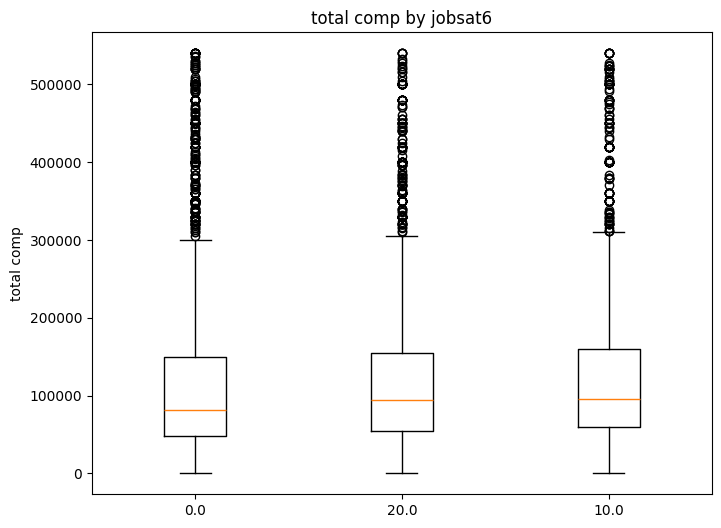

In [9]:
# your code goes here
query = """
SELECT CompTotal , JobSatPoints_6
FROM main
WHERE CompTotal IS NOT NULL
AND JobSatPoints_6 IS NOT NULL
"""

df_compsat6 = pd.read_sql_query(query , conn)
q1_compsat6 = df_compsat6['CompTotal'].describe()['25%']
q3_compsat6 = df_compsat6['CompTotal'].describe()['75%']
iqr_compsat6 = q3_compsat6 - q1_compsat6
Lbound_compsat6 = q1_compsat6 - 1.5 * iqr_compsat6
Ubound_compsat6 = q3_compsat6 + 1.5 * iqr_compsat6
df_compsat6 = df_compsat6[(df_compsat6['CompTotal'] >= Lbound_compsat6) & (df_compsat6['CompTotal'] <= Ubound_compsat6)]
#df_compsat6['JobSatPoints_6'].value_counts()
compsat6_0 = df_compsat6.loc[df_compsat6['JobSatPoints_6'] == 0.0 , 'CompTotal']
compsat6_20 = df_compsat6.loc[df_compsat6['JobSatPoints_6'] == 20.0 , 'CompTotal']
compsat6_10 = df_compsat6.loc[df_compsat6['JobSatPoints_6'] == 10.0 , 'CompTotal']
labels1 = ['0.0' , '20.0' , '10.0']
fig , ax = plt.subplots(figsize = (8 , 6))
ax.boxplot([compsat6_0 , compsat6_20 , compsat6_10] , labels = labels1)
ax.set_title('total comp by jobsat6')
ax.set_ylabel('total comp')

### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


/tmp/ipykernel_301/3647604990.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([compt1 , compt2 , compt3 , compt4 , compt5] , labels = labels2)


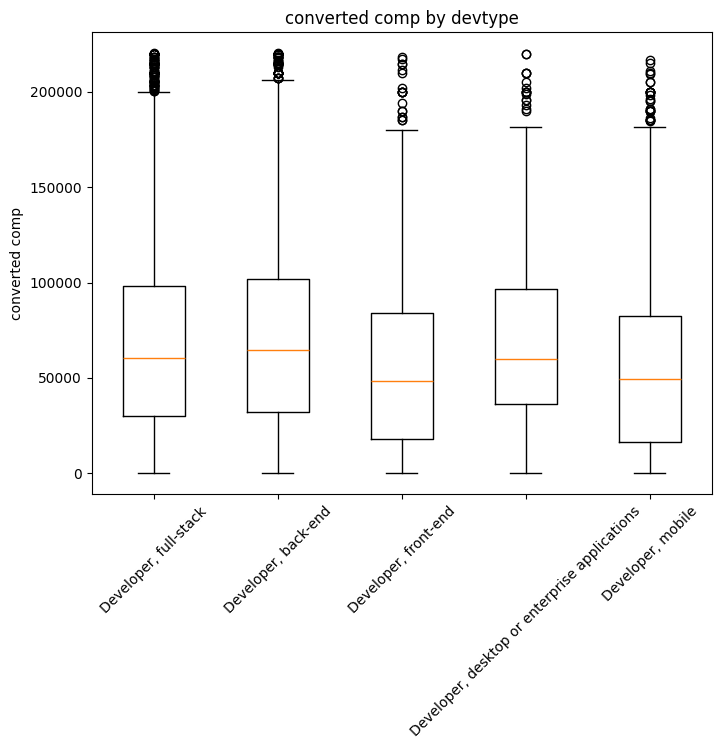

In [13]:
# your code goes here
query = """
SELECT ConvertedCompYearly , DevType
FROM main
WHERE ConvertedCompYearly IS NOT NULL
AND DevType IS NOT NULL
"""
df_compt = pd.read_sql_query(query , conn)
#df_compt['DevType'].value_counts()
q1_compt = df_compt['ConvertedCompYearly'].describe()['25%']
q3_compt = df_compt['ConvertedCompYearly'].describe()['75%']
iqr_compt = q3_compt - q1_compt
Lbound_compt = q1_compt - 1.5 * iqr_compt
Ubound_compt = q3_compt + 1.5 * iqr_compt
df_compt = df_compt[(df_compt['ConvertedCompYearly'] >= Lbound_compt) & (df_compt['ConvertedCompYearly'] <= Ubound_compt)]
compt1 = df_compt.loc[df_compt['DevType'] == 'Developer, full-stack' , 'ConvertedCompYearly']
compt2 = df_compt.loc[df_compt['DevType'] == 'Developer, back-end' , 'ConvertedCompYearly']
compt3 = df_compt.loc[df_compt['DevType'] == 'Developer, front-end' , 'ConvertedCompYearly']
compt4 = df_compt.loc[df_compt['DevType'] == 'Developer, desktop or enterprise applications' , 'ConvertedCompYearly']
compt5 = df_compt.loc[df_compt['DevType'] == 'Developer, mobile' , 'ConvertedCompYearly']
labels2 = ['Developer, full-stack' , 'Developer, back-end' , 'Developer, front-end' , 'Developer, desktop or enterprise applications' , 'Developer, mobile']
fig , ax = plt.subplots(figsize = (8 , 6))
ax.boxplot([compt1 , compt2 , compt3 , compt4 , compt5] , labels = labels2)
ax.set_title('converted comp by devtype')
ax.set_ylabel('converted comp')
ax.tick_params(axis='x', labelrotation=45)

**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


/tmp/ipykernel_301/438530407.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([compc1 , compc2 , compc3 , compc4 , compc5] , labels = labels3)


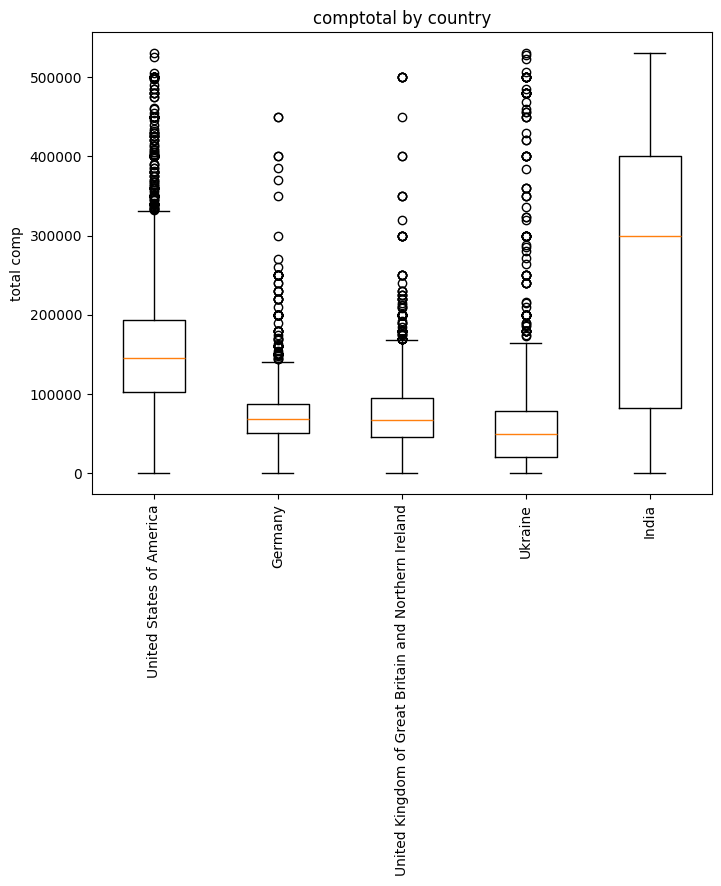

In [16]:
# your code goes here
query = """
SELECT CompTotal , Country
FROM main
WHERE CompTotal IS NOT NULL
AND Country IS NOT NULL
"""

df_compc = pd.read_sql_query(query , conn)
#df_compc['Country'].value_counts()
q1_compc = df_compc['CompTotal'].describe()['25%']
q3_compc = df_compc['CompTotal'].describe()['75%']
iqr_compc = q3_compc - q1_compc
Lbound_compc = q1_compc - 1.5 * iqr_compc
Ubound_compc = q3_compc + 1.5 * iqr_compc
df_compc = df_compc[(df_compc['CompTotal'] >= Lbound_compc) & (df_compc['CompTotal'] <= Ubound_compc)]
compc1 = df_compc.loc[df_compc['Country'] == 'United States of America' , 'CompTotal']
compc2 = df_compc.loc[df_compc['Country'] == 'Germany' , 'CompTotal']
compc3 = df_compc.loc[df_compc['Country'] == 'United Kingdom of Great Britain and Northern Ireland' , 'CompTotal']
compc4 = df_compc.loc[df_compc['Country'] == 'Ukraine' , 'CompTotal']
compc5 = df_compc.loc[df_compc['Country'] == 'India' , 'CompTotal']
labels3 = ['United States of America' , 'Germany' , 'United Kingdom of Great Britain and Northern Ireland' , 'Ukraine' , 'India']
fig , ax = plt.subplots(figsize = (8 , 6))
ax.boxplot([compc1 , compc2 , compc3 , compc4 , compc5] , labels = labels3)
ax.set_title('comptotal by country')
ax.set_ylabel('total comp')
ax.tick_params(axis='x', labelrotation=90)

### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


Text(0, 0.5, 'total comp')

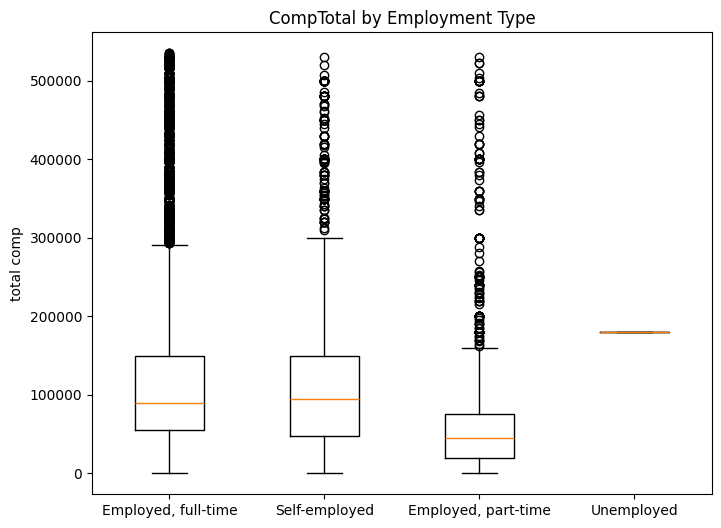

In [20]:
# your code goes here
query = """
SELECT CompTotal , Employment
FROM main
WHERE CompTotal IS NOT NULL
AND Employment IS NOT NULL
"""

df_compe = pd.read_sql_query(query , conn)
#df_compe['Employment'].value_counts()
def clean_employ(value):
    if pd.isna(value):
        return 'Unknown'

    value = value.lower()

    if 'employed, full-time' in value:
        return 'Employed, full-time'

    elif 'employed, part-time' in value:
        return 'Employed, part-time'

    elif 'self-employed' in value or 'freelancer' in value:
        return 'Self-employed'
        
    elif 'student' in value:
        return 'Student'

    elif 'not employed' in value:
        return 'Unemployed'

df_compe['EmploymentGrouped'] = df_compe['Employment'].apply(clean_employ)
#df_compe['EmploymentGrouped'].value_counts()
q1_compe = df_compe['CompTotal'].describe()['25%']
q3_compe = df_compe['CompTotal'].describe()['75%']
iqr_compe = q3_compe - q1_compe
Lbound_compe = q1_compe - 1.5 * iqr_compe
Ubound_compe = q3_compe + 1.5 * iqr_compe
df_compe = df_compe[(df_compe['CompTotal'] >= Lbound_compe) & (df_compe['CompTotal'] <= Ubound_compe)]
groups = []
labels = []
for group in df_compe['EmploymentGrouped'].dropna().unique():
    groups.append(df_compe.loc[df_compe['EmploymentGrouped'] == group , 'CompTotal'])
    labels.append(group)

fig , ax = plt.subplots(figsize = (8 , 6))
ax.boxplot(groups , tick_labels = labels)
ax.set_title('CompTotal by Employment Type')
ax.set_ylabel('total comp')

**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


Examine the distribution of professional coding years by job satisfaction levels.


Text(0, 0.5, 'years coded')

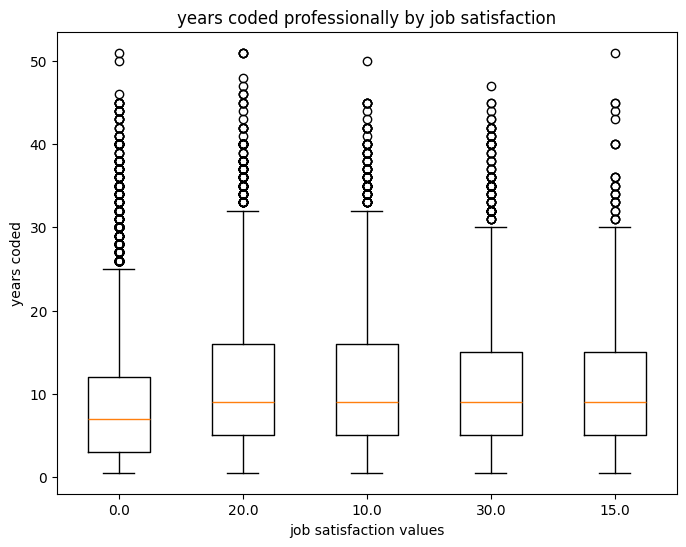

In [24]:
# your code goes here
query = """
SELECT YearsCodePro , JobSatPoints_6
FROM main
WHERE YearsCodePro IS NOT NULL
AND JobSatPoints_6 IS NOT NULL
"""

df_yj = pd.read_sql_query(query , conn)
#df_yj['YearsCodePro'].value_counts()
#df_yj['JobSatPoints_6'].value_counts()
df_yj['YearsCodePro'] = df_yj['YearsCodePro'].replace({'Less than 1 year' : 0.5 , 'More than 50 years' : 51})
df_yj['YearsCodePro'] = pd.to_numeric(df_yj['YearsCodePro'] , errors = 'coerce')
t5_js6 = df_yj['JobSatPoints_6'].value_counts().head(5).index
groups = []
labels = []
for jobsat in t5_js6:
    groups.append(df_yj.loc[df_yj['JobSatPoints_6'] == jobsat , 'YearsCodePro'])
    labels.append(str(jobsat))

fig , ax = plt.subplots(figsize = (8 , 6))
ax.boxplot(groups , tick_labels = labels)
ax.set_title('years coded professionally by job satisfaction')
ax.set_xlabel('job satisfaction values')
ax.set_ylabel('years coded')

### Final Step: Close the Database Connection


After completing the lab, close the connection to the SQLite database:


In [25]:
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
